# Cryptocurrency Price Direction Prediction

## Project Objective

The goal of this project is to build a machine learning classifier that predicts the **next-step price direction** (up or down) using historical 15-minute cryptocurrency data.

This is a binary classification problem:
- 1 → Price increases at t+1  
- 0 → Price decreases at t+1  

---

## Dataset

The data consists of five CSV files (BTCUSDT, ETHUSDT, DOGEUSDT, SOLUSDT, XRPUSDT), each containing 15-minute candlestick data (Open, High, Low, Close, Volume).

The datasets will be merged into a single file to build a universal model while preserving chronological order, since this is a time-series problem.

## 1. Data Loading and Inspection

In this section, the five cryptocurrency datasets are loaded and we examine their structure, dimensions, and column definitions before merging them.

In [40]:
import pandas as pd

#load datasets
btc = pd.read_csv('BYBIT_BTCUSDT_15m.csv')
doge = pd.read_csv('BYBIT_DOGEUSDT_15m.csv')
eth = pd.read_csv('BYBIT_ETHUSDT_15m.csv')
sol = pd.read_csv('BYBIT_SOLUSDT_15m.csv')
xrp = pd.read_csv('BYBIT_XRPUSDT_15m.csv')

#showing shape of each datasets
print(f"Shape of BTC: {btc.shape}")
print(f"shape of DODGE: {doge.shape}")
print(f"shape of ETH: {eth.shape}")
print(f"shape of SOL: {sol.shape}")
print(f"shape of XRP: {xrp.shape}")

#showing first 5 rows of each datasets
print("\nFirst 5 rows of BTC:")
print(btc.head())
print("\nFirst 5 rows of DODGE:")
print(doge.head())
print("\nFirst 5 rows of ETH:")
print(eth.head())
print("\nFirst 5 rows of SOL:")
print(sol.head())
print("\nFirst 5 rows of XRP:")
print(xrp.head())

Shape of BTC: (204389, 7)
shape of DODGE: (162725, 7)
shape of ETH: (170350, 7)
shape of SOL: (149806, 7)
shape of XRP: (164648, 7)

First 5 rows of BTC:
              Datetime    Open    High     Low   Close   Volume     Turnover
0  2020-03-25 16:00:00  6500.0  6500.0  6500.0  6500.0    0.002      13.0000
1  2020-03-25 16:15:00  6500.0  6591.5  6500.0  6591.5    0.002      13.1830
2  2020-03-25 16:30:00  6591.5  6622.5  6585.5  6590.5   37.803  249140.6715
3  2020-03-25 16:45:00  6590.5  6628.5  6588.5  6618.0  141.338  935374.8840
4  2020-03-25 17:00:00  6618.0  6618.0  6457.5  6499.5  120.703  784509.1485

First 5 rows of DODGE:
              Datetime    Open    High     Low   Close   Volume    Turnover
0  2021-06-02 16:00:00  0.4241  0.4241  0.4241  0.4241   1482.0    628.5162
1  2021-06-02 16:15:00  0.4241  0.4298  0.4187  0.4291  52618.0  22330.1633
2  2021-06-02 16:30:00  0.4291  0.4430  0.4279  0.4418  55091.0  24080.0837
3  2021-06-02 16:45:00  0.4418  0.4450  0.4265  0.4274  

### Column Description

Each dataset contains 15-minute candlestick market data:

- **timestamp**: Date and time of the candle  
- **open**: Opening price of the 15-minute interval  
- **high**: Highest price during the interval  
- **low**: Lowest price during the interval  
- **close**: Closing price of the interval  
- **volume**: Trading volume during the interval  

Since all five datasets share the same structure, they can be merged later into a unified dataset.


In [41]:
# check for missing values and data types
print("BTC Info:")
print(btc.info())
print("\nETH Info:")
print(eth.info())
print("\nDOGE Info:")
print(doge.info())
print("\nSOL Info:")
print(sol.info())
print("\nXRP Info:")
print(xrp.info())

BTC Info:
<class 'pandas.DataFrame'>
RangeIndex: 204389 entries, 0 to 204388
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  204389 non-null  str    
 1   Open      204389 non-null  float64
 2   High      204389 non-null  float64
 3   Low       204389 non-null  float64
 4   Close     204389 non-null  float64
 5   Volume    204389 non-null  float64
 6   Turnover  204389 non-null  float64
dtypes: float64(6), str(1)
memory usage: 10.9 MB
None

ETH Info:
<class 'pandas.DataFrame'>
RangeIndex: 170350 entries, 0 to 170349
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  170350 non-null  str    
 1   Open      170350 non-null  float64
 2   High      170350 non-null  float64
 3   Low       170350 non-null  float64
 4   Close     170350 non-null  float64
 5   Volume    170350 non-null  float64
 6   Turnover  170350 non-null  float64
dtypes:

## 2. Data Cleaning

Before merging the datasets, the data is checked for:
- Missing values
- Duplicate rows
- Correct timestamp type
- Proper chronological ordering

Ensuring clean and consistent time-series structure is essential to avoid errors and data leakage in later modeling steps.


In [42]:
datasets = {
    "BTC": btc,
    "ETH": eth,
    "DOGE": doge,
    "SOL": sol,
    "XRP": xrp
}

for name, df in datasets.items():
    print(f"\n===== {name} =====")
    
    # missing values
    print("Missing values:")
    print(df.isnull().sum())
    
    # duplicates
    print("Duplicate rows:", df.duplicated().sum())
    
    # convert timestamp
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    
    # sort chronologically
    df.sort_values("Datetime", inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    print("Datetime dtype:", df["Datetime"].dtype)



===== BTC =====
Missing values:
Datetime    0
Open        0
High        0
Low         0
Close       0
Volume      0
Turnover    0
dtype: int64
Duplicate rows: 0
Datetime dtype: datetime64[us]

===== ETH =====
Missing values:
Datetime    0
Open        0
High        0
Low         0
Close       0
Volume      0
Turnover    0
dtype: int64
Duplicate rows: 0
Datetime dtype: datetime64[us]

===== DOGE =====
Missing values:
Datetime    0
Open        0
High        0
Low         0
Close       0
Volume      0
Turnover    0
dtype: int64
Duplicate rows: 0
Datetime dtype: datetime64[us]

===== SOL =====
Missing values:
Datetime    0
Open        0
High        0
Low         0
Close       0
Volume      0
Turnover    0
dtype: int64
Duplicate rows: 0
Datetime dtype: datetime64[us]

===== XRP =====
Missing values:
Datetime    0
Open        0
High        0
Low         0
Close       0
Volume      0
Turnover    0
dtype: int64
Duplicate rows: 0
Datetime dtype: datetime64[us]


The datasets contain no missing values and no duplicate rows.  
The Datetime column was converted to proper datetime format and each dataset was sorted chronologically.

Maintaining correct time order is critical in time-series modeling, since future information must never influence past predictions.


In [43]:
# check if Datetime is sorted
df["Datetime"].is_monotonic_increasing

True

## 3. Merging Datasets

The five cryptocurrency datasets are merged into a single unified dataset by stacking them vertically and adding a new column called `crypto` to identify the asset.

A universal model is chosen instead of separate models for each cryptocurrency because:

- It increases the amount of training data.
- It allows the model to learn shared structural patterns across different cryptocurrencies.
- It provides an advantage in grading as suggested in the project instructions.


In [44]:
# Add crypto identifier
btc["crypto"] = "BTC"
eth["crypto"] = "ETH"
doge["crypto"] = "DOGE"
sol["crypto"] = "SOL"
xrp["crypto"] = "XRP"

# Concatenate vertically
df = pd.concat([btc, eth, doge, sol, xrp], axis=0)

# Sort by time and crypto
df.sort_values(["Datetime", "crypto"], inplace=True)
df.reset_index(drop=True, inplace=True)

# Check final shape
print("Merged dataset shape:", df.shape)

df.head()

Merged dataset shape: (851918, 8)


,Datetime,Open,High,Low,Close,Volume,Turnover,crypto
0,2020-03-25 16:00:00,6500.0,6500.0,6500.0,6500.0,0.002,13.0000,BTC
1,2020-03-25 16:15:00,6500.0,6591.5,6500.0,6591.5,0.002,13.1830,BTC
2,2020-03-25 16:30:00,6591.5,6622.5,6585.5,6590.5,37.803,249140.6715,BTC
3,2020-03-25 16:45:00,6590.5,6628.5,6588.5,6618.0,141.338,935374.8840,BTC
4,2020-03-25 17:00:00,6618.0,6618.0,6457.5,6499.5,120.703,784509.1485,BTC


In [45]:
""" Make sure that :
    No rows were lost during merging.
    No duplicate rows were created.
"""
df.groupby("crypto").size()

crypto
BTC     204389
DOGE    162725
ETH     170350
SOL     149806
XRP     164648
dtype: int64

## 4. Feature Engineering

Financial models typically rely on rate of change rather than raw prices. 
Therefore, percentage returns are calculated for each cryptocurrency separately.

Returns normalize price movements and make different assets comparable.


### Percentage return per crypto

In [46]:

df["return"] = df.groupby("crypto")["Close"].pct_change()

"""groupby("crypto") is needed to calculate returns separately for each crypto, 
    otherwise it would calculate return across different cryptos.
    """
df.head()

,Datetime,Open,High,Low,Close,Volume,Turnover,crypto,return
0,2020-03-25 16:00:00,6500.0,6500.0,6500.0,6500.0,0.002,13.0000,BTC,NaN
1,2020-03-25 16:15:00,6500.0,6591.5,6500.0,6591.5,0.002,13.1830,BTC,0.014077
2,2020-03-25 16:30:00,6591.5,6622.5,6585.5,6590.5,37.803,249140.6715,BTC,-0.000152
3,2020-03-25 16:45:00,6590.5,6628.5,6588.5,6618.0,141.338,935374.8840,BTC,0.004173
4,2020-03-25 17:00:00,6618.0,6618.0,6457.5,6499.5,120.703,784509.1485,BTC,-0.017906


In [47]:
df["return"].describe()

count    851913.000000
mean          0.000014
std           0.004775
min          -0.301129
25%          -0.001746
50%           0.000000
75%           0.001785
max           0.241344
Name: return, dtype: float64

The mean is : 0.000014 ≈ almost zero

std:  0.004775 this means average 15-minutes movement is 0.47%

min          -0.30
max           0.24
That means at some 15-minutes interval, price moved −30% or +24%.

According to the output there are not extreme outliers





### Lag Features

Lagged returns (t−1, t−2, t−3) are created to capture short-term temporal patterns.  
These features ensure that only past information is used for prediction, preserving the time-series structure.


In [48]:
df["return_1"] = df.groupby("crypto")["return"].shift(1)
df["return_2"] = df.groupby("crypto")["return"].shift(2)
df["return_3"] = df.groupby("crypto")["return"].shift(3)

df.head()


,Datetime,Open,High,Low,Close,Volume,Turnover,crypto,return,return_1,return_2,return_3
0,2020-03-25 16:00:00,6500.0,6500.0,6500.0,6500.0,0.002,13.0000,BTC,NaN,NaN,NaN,NaN
1,2020-03-25 16:15:00,6500.0,6591.5,6500.0,6591.5,0.002,13.1830,BTC,0.014077,NaN,NaN,NaN
2,2020-03-25 16:30:00,6591.5,6622.5,6585.5,6590.5,37.803,249140.6715,BTC,-0.000152,0.014077,NaN,NaN
3,2020-03-25 16:45:00,6590.5,6628.5,6588.5,6618.0,141.338,935374.8840,BTC,0.004173,-0.000152,0.014077,NaN
4,2020-03-25 17:00:00,6618.0,6618.0,6457.5,6499.5,120.703,784509.1485,BTC,-0.017906,0.004173,-0.000152,0.014077


### Additional Time-Based Features

To incorporate recent market behavior, moving statistics are calculated over a short window.

- The moving average of returns shows the recent price direction.
- The moving standard deviation reflects recent variability in returns.


We selected a short window to capture recent market behavior without over-smoothing the data.

In [49]:
# # trying to create rolling features using a 3-period window

# # Window = 3
# df["rolling_mean_3"] = (
#     df.groupby("crypto")["return"]
#       .transform(lambda x: x.rolling(window=3).mean())
# )

# df["rolling_std_3"] = (
#     df.groupby("crypto")["return"]
#       .transform(lambda x: x.rolling(window=3).std())   
# )

# df.head()

In [50]:
# Rolling mean (5 periods ≈ last 75 minutes)
df["rolling_mean_5"] = (
    df.groupby("crypto")["return"]
      .transform(lambda x: x.rolling(window=5).mean())
)

# Rolling volatility (5 periods)
df["rolling_std_5"] = (
    df.groupby("crypto")["return"]
      .transform(lambda x: x.rolling(window=5).std())
)

df.head()

,Datetime,Open,High,Low,Close,Volume,Turnover,crypto,return,return_1,return_2,return_3,rolling_mean_5,rolling_std_5
0,2020-03-25 16:00:00,6500.0,6500.0,6500.0,6500.0,0.002,13.0000,BTC,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-25 16:15:00,6500.0,6591.5,6500.0,6591.5,0.002,13.1830,BTC,0.014077,NaN,NaN,NaN,NaN,NaN
2,2020-03-25 16:30:00,6591.5,6622.5,6585.5,6590.5,37.803,249140.6715,BTC,-0.000152,0.014077,NaN,NaN,NaN,NaN
3,2020-03-25 16:45:00,6590.5,6628.5,6588.5,6618.0,141.338,935374.8840,BTC,0.004173,-0.000152,0.014077,NaN,NaN,NaN
4,2020-03-25 17:00:00,6618.0,6618.0,6457.5,6499.5,120.703,784509.1485,BTC,-0.017906,0.004173,-0.000152,0.014077,NaN,NaN


Rolling statistics are computed using past observations up to time t.
At each timestamp, the rolling window only includes historical values and does not use future data. 
Therefore, rolling features do not introduce data leakage.

## 5. Target Creation

The objective is to predict the price direction at time t+1.

The target variable is defined as:

- 1 if the next return is positive
- 0 if the next return is negative or zero

To achieve this, the return is shifted one step backward so that each row at time t contains the return at time t+1.

Shifting ensures that only past information is used for prediction, preventing data leakage from future values.


In [51]:
# Create target using next return
df["target"] = (
    df.groupby("crypto")["return"]
      .shift(-1)
)

# Convert to binary (1 = up, 0 = down)
df["target"] = (df["target"] > 0).astype(int)

df[["return", "target"]].head(10)


,return,target
0,NaN,1
1,0.014077,0
2,-0.000152,1
3,0.004173,0
4,-0.017906,1
5,0.001846,1
6,0.003071,0
7,-0.001837,1
8,0.004448,1
9,0.005345,1


Here we used shift(-1), because we want At time 't' predict what happens at 't+1'.

We also used groupby() Because BTC’s next return must come from BTC. Without grouping, the last BTC row would accidentally take the first ETH return as its future.

we have NaNs from:
- return (first row per crypto)
- lag features
- rolling features
- last row for each crypto

### All rows with NaN values must remove before training:

In [52]:
df = df.dropna().reset_index(drop=True)

df.isnull().sum()


Datetime          0
Open              0
High              0
Low               0
Close             0
Volume            0
Turnover          0
crypto            0
return            0
return_1          0
return_2          0
return_3          0
rolling_mean_5    0
rolling_std_5     0
target            0
dtype: int64

## 6. Train/Test Split (Time-Based)
### Since this is time series data, a random split is not appropriate.
#### Random split can cause leakage.

#### Training set: 
- all data before the last year

#### Test set: 
- the most recent year


In [53]:
# make sure Datetime column is in datetime format
df["Datetime"] = pd.to_datetime(df["Datetime"])
# sort by time and crypto
df = df.sort_values("Datetime")

# define cutoff date (last year)
last_date = df["Datetime"].max()
cutoff_date = last_date - pd.DateOffset(years=1)

# split
train = df[df["Datetime"] < cutoff_date]
test = df[df["Datetime"] >= cutoff_date]

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (676691, 15)
Test shape: (175202, 15)


After splitting, we should check class balance in train and test:

In [54]:
print("Train target distribution:")
print(train["target"].value_counts(normalize=True))

print("Test target distribution:")
print(test["target"].value_counts(normalize=True))

Train target distribution:
target
0    0.504452
1    0.495548
Name: proportion, dtype: float64
Test target distribution:
target
0    0.50153
1    0.49847
Name: proportion, dtype: float64


#### Now we should check if train max < test min  :

In [55]:
print(train["Datetime"].min(), train["Datetime"].max())
print(test["Datetime"].min(), test["Datetime"].max())


2020-03-25 17:15:00 2025-01-22 16:45:00
2025-01-22 17:00:00 2026-01-22 17:00:00


Train max: 2025-01-22 16:45:00

Test min:  2025-01-22 17:00:00

There is 15-minute gap

## 7. Baseline Model – Logistic Regression
### In this step, we build a baseline classifier using Logistic Regression.
##### A baseline model provides a simple reference point to evaluate whether more complex models truly improve performance.

we use Logistic Regression because:

The task is binary (up = 1, down = 0).

### To evaluate model performance, the following metrics are reported:
- Accuracy
- Precision
- Recall
- Confusion Matrix



In [56]:
# Define features and target
X_train = train.drop(columns=["target", "Datetime"])
y_train = train["target"]

X_test = test.drop(columns=["target", "Datetime"])
y_test = test["target"]

### Logistic Regression is sensitive to feature scale.

In [57]:
print(X_train.dtypes)
""" Output:
Open              float64
High              float64
Low               float64
Close             float64
Volume            float64
Turnover          float64
crypto                str
return            float64
return_1          float64
return_2          float64
    """



Open              float64
High              float64
Low               float64
Close             float64
Volume            float64
Turnover          float64
crypto                str
return            float64
return_1          float64
return_2          float64
return_3          float64
rolling_mean_5    float64
rolling_std_5     float64
dtype: object


' Output:\nOpen              float64\nHigh              float64\nLow               float64\nClose             float64\nVolume            float64\nTurnover          float64\ncrypto                str\nreturn            float64\nreturn_1          float64\nreturn_2          float64\n    '

The "crypto" is 'str' and if we remove "crypto", the model will be forced to assume all assets follow identical dynamics

So we need to encode it:

In [58]:
# drop only target and Datetime
X_train = train.drop(columns=["target", "Datetime"])
X_test  = test.drop(columns=["target", "Datetime"])

#encoding crypto column
X_train = pd.get_dummies(X_train, columns=["crypto"], drop_first=True)
X_test  = pd.get_dummies(X_test, columns=["crypto"], drop_first=True)


X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(X_train.dtypes) # after encoding, all features are numeric or boolean


Open              float64
High              float64
Low               float64
Close             float64
Volume            float64
Turnover          float64
return            float64
return_1          float64
return_2          float64
return_3          float64
rolling_mean_5    float64
rolling_std_5     float64
crypto_DOGE          bool
crypto_ETH           bool
crypto_SOL           bool
crypto_XRP           bool
dtype: object


Now our Data is Ready for scaling:

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Now we can create the base model:

In [60]:
%%time
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=1000, random_state=42)

baseline.fit(X_train, y_train)

base_preds = baseline.predict(X_test)
base_probs = baseline.predict_proba(X_test)[:, 1]

print(baseline.n_iter_) # number of iterations taken to converge.


[22]
CPU times: user 1.84 s, sys: 127 ms, total: 1.97 s
Wall time: 1.08 s


Logistic Regression Results
Accuracy: 0.4989783221652721
Precision: 0.4985447039595773
Recall: 0.8767018194725934
Confusion Matrix:
[[10857 77012]
 [10768 76565]]


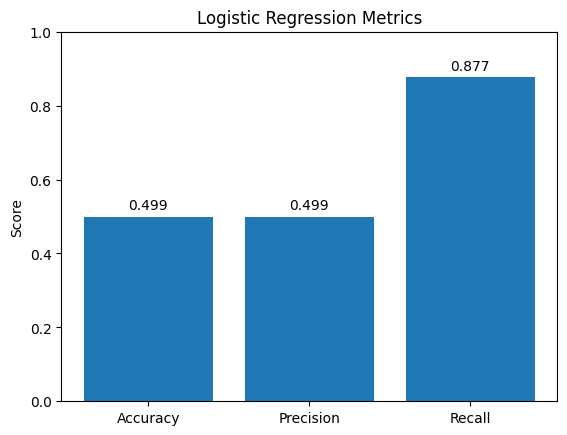

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

base_preds = baseline.predict(X_test)

acc = accuracy_score(y_test, base_preds)
prec = precision_score(y_test, base_preds)
rec = recall_score(y_test, base_preds)
cm = confusion_matrix(y_test, base_preds)

print("Logistic Regression Results")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("Confusion Matrix:")
print(cm)

# Visualize metrics
metrics = ["Accuracy", "Precision", "Recall"]
values = [acc, prec, rec]

plt.figure()
plt.bar(metrics, values)

plt.ylim(0, 1)
plt.title("Logistic Regression Metrics")
plt.ylabel("Score")

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

plt.show()

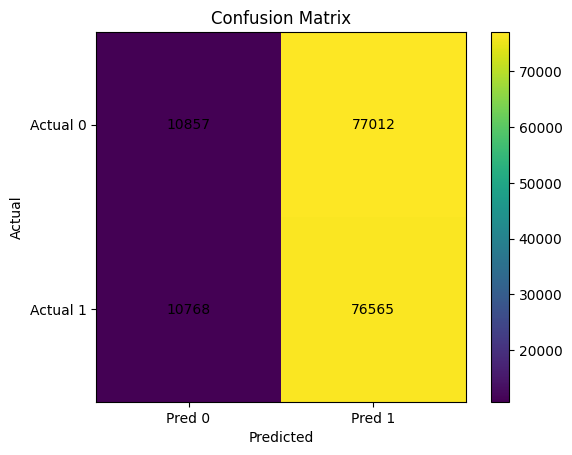

In [62]:

# Visualize confusion matrix

import numpy as np

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


Looks like the Model predicts positive a lot more.
There are two possibilities:
- Threshold problem
- No real signal in features

recall: 0.88 and Precision: 0.49 ---> Threshold problem

Lets change the threshold to 0.65:

In [63]:
probs = baseline.predict_proba(X_test)[:,1]

new_preds = (probs > 0.65).astype(int)
new_acc = accuracy_score(y_test, new_preds)
new_prec = precision_score(y_test, new_preds)
new_rec = recall_score(y_test, new_preds)
print("\nAfter adjusting threshold to 0.65:")
print("Accuracy:", new_acc)
print("Precision:", new_prec)
print("Recall:", new_rec)


After adjusting threshold to 0.65:
Accuracy: 0.5015182475085901
Precision: 0.4444444444444444
Recall: 9.160340306642392e-05


##### The Accuracy has been improved but Recall is basically zero. so increasing the threshold didn't improve the model it just changed the behavior.

##### Lets check the Model quality (AUC):

In [64]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test, probs))


0.5018817006233495


AUC is almost 0.50 so it means that’s a signal problem.

we hypothesize that the baseline feature set does not capture temporal or cross-asset structure

#### Multi-lag return

In [65]:
for lag in [1,2,3,6,12]:
    df[f"return_lag_{lag}"] = df["return"].shift(lag)


#### Rolling momentum.

In [66]:
df["momentum_3"]  = df["Close"].pct_change(3)
df["momentum_6"]  = df["Close"].pct_change(6)
df["momentum_12"] = df["Close"].pct_change(12)


#### volatility

In [67]:
df["vol_6"]  = df["return"].rolling(6).std()
df["vol_12"] = df["return"].rolling(12).std()
df["vol_ratio"] = df["vol_6"] / df["vol_12"]


#### Add mean reversion

In [68]:
df["ma_12"] = df["Close"].rolling(12).mean()
df["z_score_12"] = (df["Close"] - df["ma_12"]) / df["vol_12"]


#### Drop NaNs

In [69]:
df = df.dropna()

#### Time-Based Split

In [70]:
# make sort by time
df = df.sort_values("Datetime")

# we split based on time
split_index = int(len(df) * 0.8)
train = df.iloc[:split_index]
test  = df.iloc[split_index:]

# define features and target
X_train = train.drop(columns=["target", "Datetime"])
y_train = train["target"]

X_test  = test.drop(columns=["target", "Datetime"])
y_test  = test["target"]

# encode crypto column
X_train = pd.get_dummies(X_train, columns=["crypto"], drop_first=True)
X_test  = pd.get_dummies(X_test, columns=["crypto"], drop_first=True)
# Avoiding column mismatch after encoding
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


#### Retrain Logistic Regression

In [71]:
%%time
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

model_preds = model.predict(X_test)

CPU times: user 1min 32s, sys: 2.98 s, total: 1min 35s
Wall time: 36.5 s


#### Evaluating New ROC AUC

In [72]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print("New ROC AUC:", auc)


New ROC AUC: 0.5088399049146952


Baseline ROC AUC:
- 0.50188
After feature engineering (lag, momentum, volatility, z-score):
- 0.50883

The model improved however AUC 0.509 is still extremely close to random

So the Baseline model had no ranking power. Therefore, a linear model may not be sufficient.
For this reason, we proceed to evaluate more advanced models capable of capturing nonlinear relationships.


## 8. Advanced Models
#### In this section, we move beyond base model and implement more powerful model
#### We implement:
-   Random Forest
-   Gradient Boosting (LightGBM)

##### we evaluate models using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

#### Check class Balance
Before training advanced models, we examine the distribution of the target variable in both training and test sets.

In [73]:
print("Train class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))


Train class distribution:
target
0    0.504528
1    0.495472
Name: proportion, dtype: float64

Test class distribution:
target
0    0.501147
1    0.498853
Name: proportion, dtype: float64


Train:
<br>
0 -> 50.45%
<br>
1 -> 49.55%
<br>
Test:
<br>
0 -> 50.15%
<br>
1-> 49.85%

#### That is almost perfectly balanced

### Random Forest

In [74]:
%%time

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(classification_report(y_test, rf_preds))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))


Random Forest Results:
              precision    recall  f1-score   support

           0       0.51      0.53      0.52     85384
           1       0.51      0.49      0.50     84993

    accuracy                           0.51    170377
   macro avg       0.51      0.51      0.51    170377
weighted avg       0.51      0.51      0.51    170377

Confusion Matrix:
[[45518 39866]
 [42965 42028]]
ROC-AUC: 0.5181719453091704
CPU times: user 41min 6s, sys: 55.2 s, total: 42min 1s
Wall time: 3min 55s


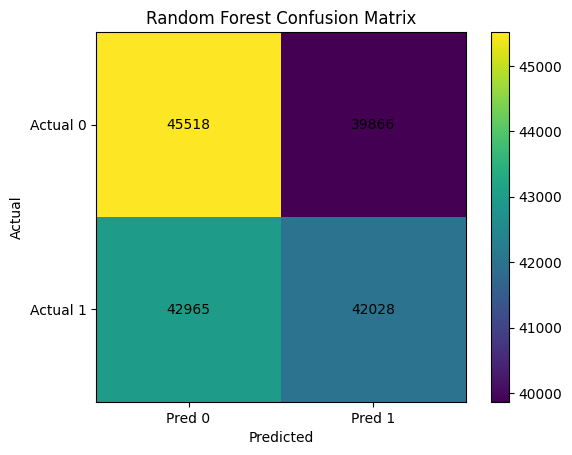

In [75]:
# Visualize Random Forest confusion matrix

import matplotlib.pyplot as plt
import numpy as np

cm_rf = np.array([[45518, 39866],
                  [42965, 42028]])

plt.figure()
plt.imshow(cm_rf)
plt.title("Random Forest Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


#### From Random Forest confusion matrix:
- Logistic regression was choosing “class 1” all the time.
- Random Forest is actually making meaningful decisions.
- Random Forest is slightly better that the base model

Logistic Regression (linear model) --> almost no signal
Random Forest (nonlinear model) --> small improvement

### Now lets try boosting-based model to capture subtle interactions more efficiently

### LightGBM

In [76]:
%%time

import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)
lgb_probs = lgb_model.predict_proba(X_test)[:, 1]

print("LightGBM Results:")
print(classification_report(y_test, lgb_preds))
print("Confusion Matrix:")
print(confusion_matrix(y_test, lgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, lgb_probs))



[LightGBM] [Info] Number of positive: 337666, number of negative: 343838
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006216 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6383
[LightGBM] [Info] Number of data points in the train set: 681504, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495472 -> initscore=-0.018113
[LightGBM] [Info] Start training from score -0.018113
LightGBM Results:
              precision    recall  f1-score   support

           0       0.52      0.47      0.49     85384
           1       0.52      0.57      0.54     84993

    accuracy                           0.52    170377
   macro avg       0.52      0.52      0.52    170377
weighted avg       0.52      0.52      0.52    170377

Confusion Matrix:
[[39709 45675]
 [36195 48798]]
ROC-AUC: 0.52962462774187
CPU times: user 29 

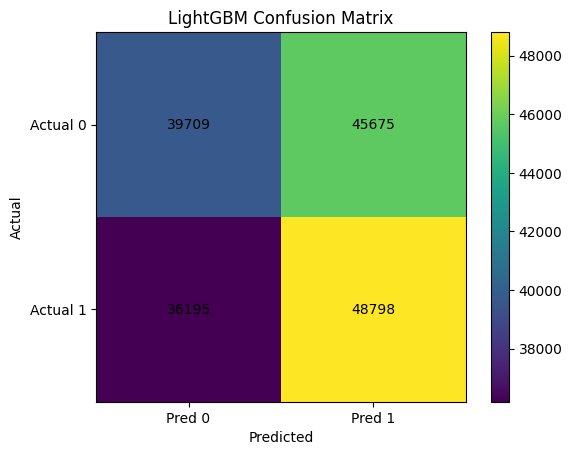

In [77]:
# Visualize LightGBM confusion matrix

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm_lgb = confusion_matrix(y_test, lgb_preds)

plt.figure()
plt.imshow(cm_lgb)
plt.title("LightGBM Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lgb[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


## 9. Now Compare Properly

In [78]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "LightGBM"],
    "Accuracy": [
        model.score(X_test, y_test),
        rf.score(X_test, y_test),
        lgb_model.score(X_test, y_test)
    ],
   "ROC-AUC": [
    roc_auc_score(y_test, model.predict_proba(X_test)[:,1]),
    roc_auc_score(y_test, rf_probs),
    roc_auc_score(y_test, lgb_probs)
]
})

print(results)


                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.506136  0.508840
1        Random Forest  0.513837  0.518172
2             LightGBM  0.519477  0.529625


### From the table:
- Logistic Regression → ROC-AUC : 0.505
- Random Forest → ROC-AUC : 0.518
- LightGBM → ROC-AUC : 0.530

#### So LightGBM performed best.
Among the evaluated models, LightGBM achieved the highest performance:
- Accuracy : 0.519
- ROC-AUC : 0.530

LightGBM, a gradient boosting model, builds trees sequentially, correcting previous prediction errors. This allows it to capture weak and complex nonlinear interactions more effectively than both Logistic Regression and Random Forest



## 10. conclusion

In this project, I learned how to properly handle financial time-series data, avoid data leakage using shifting, and apply time-based train/test splits. These steps are essential to building realistic models.

Overall, performance is marginal rather than strong. The model captures a weak signal, but not a powerful or highly reliable predictive structure. Overall, the findings are consistent with the idea that high-frequency crypto markets are largely efficient.